# 📈 第 90 课 · 华为全栈 AI 框架演进

> 从昇腾芯片到 MindSpore、CANN、MindIE 的七年快车(本章收官)

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 把第 81~89 课的知识放进一条时间线:硬件、CANN、MindSpore、引擎
- 掌握昇腾硬件代际:310 / 910 / 910B / 910C 的算力爬坡
- 掌握 CANN 版本演进:从 5.x 到 9.x 的架构升级
- 理解 MindSpore 2.x 的定位变化:训练/推理/端云一体
- 看懂昇腾生态与 PyTorch / vLLM 生态的融合关系

## 📑 本课目录

1. **直觉:七年开出一列车** — 硬件打底、软件织网、生态提速
2. **全栈时间线(2018→2026)** — 一张 matplotlib 时间轴看懂全貌
3. **昇腾硬件代际** — 310/910/910B/910C 的算力爬坡
4. **CANN 版本演进** — 5.x→9.x:从“配套”到“平台”
5. **MindSpore 2.x 新航向** — 端云一体、自动并行、生态融合
6. **与 PyTorch/vLLM 生态的关系** — torch_npu、vLLM-Ascend 的开源协作
7. **展望:下一站** — 软硬协同的下一个十年

## 🔗 参考资料

- [昇腾社区](https://www.hiascend.com)
- [MindSpore 官网](https://www.mindspore.cn)
- [vLLM-Ascend GitHub](https://github.com/vllm-project/vllm-ascend)

## 1️⃣ 直觉:七年开出一列车 🚆

把华为的 AI 栈想成一列火车:**硬件是轨道,软件是车厢,生态是车站**。

- **2018~2019**:铺轨——昇腾 310/910 芯片发布;
- **2020~2022**:挂第一节车厢——MindSpore 开源,从 1.0 狂奔到 1.9;
- **2023**:换轨提速——昇腾 910B 量产、MindSpore 2.0 重构;
- **2024~2025**:编组大列——CANN 8/9、MindIE、vLLM-Ascend 陆续入列;
- **2026**:并网互通——昇腾生态与 PyTorch / vLLM 生态深度握手。

下面这张**时间线图**就是全书的“地图册”:把第 81~89 课讲过的每一块,放回它出生的年份。

✅ 第一段代码:KMP 保护 + 固定 seed + 会议论文风绘图环境。本机无昇腾硬件,时间线/代际数据按公开资料整理为“示意”。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # Windows OMP 冲突防护
import math, json, time, numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font=["Microsoft YaHei", "DejaVu Sans"])
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(0); np.random.seed(0)

print("torch  :", torch.__version__)
print("注意: 本机无昇腾硬件 / MindSpore,本课用 torch 类比 + matplotlib 图示讲解真实概念。")

torch  : 2.11.0+cu128
注意: 本机无昇腾硬件 / MindSpore,本课用 torch 类比 + matplotlib 图示讲解真实概念。


📈 时间轴把四层栈的演进对齐:每一代硬件都有对应的软件版本“随行”。看这一张图,全书的昇腾篇章就有了坐标。

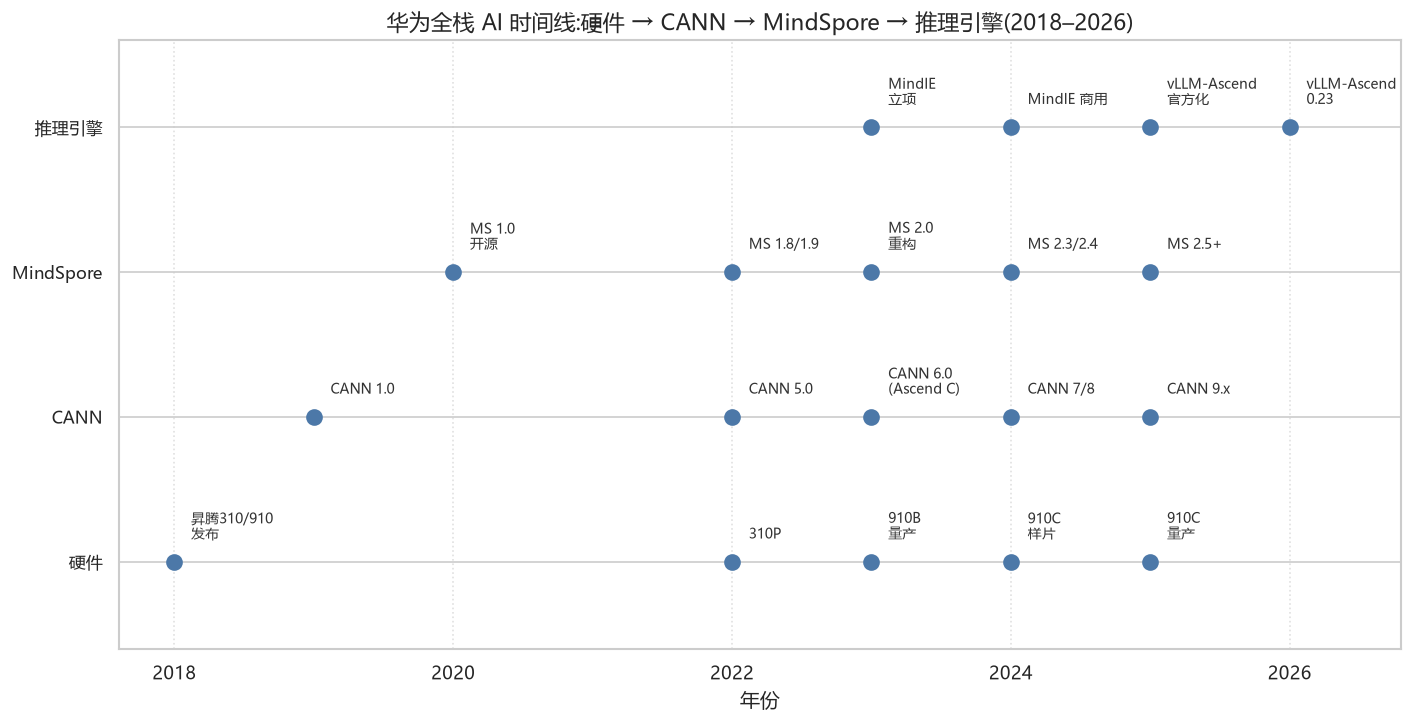

In [2]:
fig, ax = plt.subplots(figsize=(12, 6.2))
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
events = {
    "硬件": [(2018, "昇腾310/910\n发布"), (2022, "310P"), (2023, "910B\n量产"),
             (2024, "910C\n样片"), (2025, "910C\n量产")],
    "CANN": [(2019, "CANN 1.0"), (2022, "CANN 5.0"), (2023, "CANN 6.0\n(Ascend C)"),
             (2024, "CANN 7/8"), (2025, "CANN 9.x")],
    "MindSpore": [(2020, "MS 1.0\n开源"), (2022, "MS 1.8/1.9"), (2023, "MS 2.0\n重构"),
                  (2024, "MS 2.3/2.4"), (2025, "MS 2.5+")],
    "推理引擎": [(2023, "MindIE\n立项"), (2024, "MindIE 商用"), (2025, "vLLM-Ascend\n官方化"),
               (2026, "vLLM-Ascend\n0.23")],
}
rows = list(events)
for r, row in enumerate(rows):
    for y, label in events[row]:
        ax.plot(y, r, "o", ms=9, color="#4C78A8", zorder=3)
        ax.annotate(label, xy=(y, r), xytext=(y + 0.12, r + 0.16), fontsize=8.5, color="#333")
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=10)
ax.set_xlim(2017.6, 2026.8); ax.set_ylim(-0.6, 3.6)
ax.set_xlabel("年份")
ax.set_title("华为全栈 AI 时间线:硬件 → CANN → MindSpore → 推理引擎(2018–2026)", fontsize=13)
ax.grid(axis="x", ls=":", alpha=0.6)
plt.tight_layout(); plt.show()

## 2️⃣ 昇腾硬件代际:算力爬坡 📊

昇腾芯片的代际演进,本质是 **AICore(AI 计算核)密度与带宽** 的爬坡:

- **昇腾 310**(2018 发布):边缘推理,主打低功耗;
- **昇腾 910**(2019):第一代训练芯片,FP16 算力 ~256 TFLOPS;
- **910B**(2023):Atlas 800T A2 的核心,FP16 算力提升约 1.5×;
- **910C**(2024~2025):新一代旗舰,FP16 算力进一步翻倍,支撑百万 token 长上下文与千亿 MoE。

画一条“算力代际爬坡”曲线:

📊 注意单位跨度:310 是“TOPS 级”(边缘),910 起才进入“TFLOPS 级”。每一代软件(CANN/MindIE)都跟着芯片重写一遍优化。

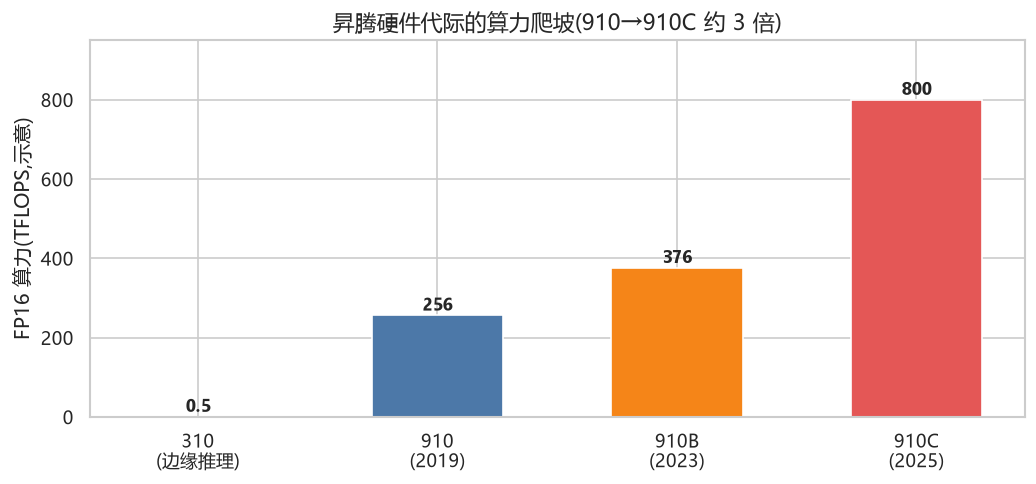

In [3]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
gens = ["310\n(边缘推理)", "910\n(2019)", "910B\n(2023)", "910C\n(2025)"]
fp16 = [0.5, 256, 376, 800]      # TFLOPS(示意:公开量级)
ax.bar(gens, fp16, color=["#B8C4D8", "#4C78A8", "#F58518", "#E45756"], width=0.55)
for i, v in enumerate(fp16):
    ax.text(i, v + 12, f"{v}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("FP16 算力(TFLOPS,示意)")
ax.set_title("昇腾硬件代际的算力爬坡(910→910C 约 3 倍)", fontsize=13)
ax.set_ylim(0, 950)
plt.tight_layout(); plt.show()

## 3️⃣ CANN 版本演进:从“配套”到“平台” 🗃️

CANN 的版本史可以概括成三次跃迁:

- **5.x(2022)**:算子与运行时基本成型,还像 CUDA 的“昇腾简化版”;
- **6.0(2023)**:发布 **Ascend C** 统一算子编程语言,开发者终于有“昇腾的 CUDA C”;
- **8.0/9.x(2024~2025)**:解耦硬件版本、支持 910B/910C、深度服务 LLM(融合注意力、
  MoE、长序列)。

画一条“CANN 能力成熟度”随版本爬坡的曲线:

📊 CANN 从“跟着芯片走”到“定义编程范式”再到“服务大模型”,三步完成平台化。

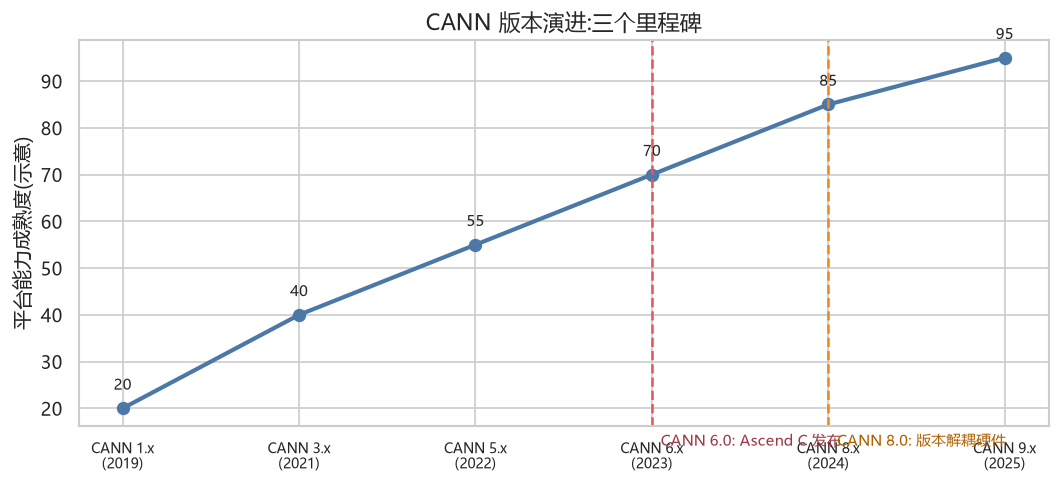

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ver = ["CANN 1.x\n(2019)", "CANN 3.x\n(2021)", "CANN 5.x\n(2022)", "CANN 6.x\n(2023)",
       "CANN 8.x\n(2024)", "CANN 9.x\n(2025)"]
cap = [20, 40, 55, 70, 85, 95]
ax.plot(range(len(ver)), cap, "o-", color="#4C78A8", lw=2.5, ms=7)
for i, v in enumerate(cap):
    ax.annotate(str(v), xy=(i, v), xytext=(i, v + 4), ha="center", fontsize=9)
ax.axvline(3, color="#E45756", ls="--", lw=1.5)
ax.text(3.05, 12, "CANN 6.0: Ascend C 发布", fontsize=9, color="#A03A45")
ax.axvline(4, color="#F58518", ls="--", lw=1.5)
ax.text(4.05, 12, "CANN 8.0: 版本解耦硬件", fontsize=9, color="#B06000")
ax.set_xticks(range(len(ver))); ax.set_xticklabels(ver, fontsize=8.5)
ax.set_ylabel("平台能力成熟度(示意)")
ax.set_title("CANN 版本演进:三个里程碑", fontsize=13)
plt.tight_layout(); plt.show()

## 4️⃣ MindSpore 2.x 的新航向 🧭

2023 年的 **MindSpore 2.0** 是一次“重新出发”,标志性变化:

1. **新接口范式**:`nn.Cell` + PyNative 动态图默认,训练体验向 PyTorch 对齐;
2. **端云一体**:训练用大模型、推理下沉端侧(Lite),一套代码多端部署;
3. **自动并行成熟**:AUTO_PARALLEL 的策略搜索成为多卡训练的主力;
4. **生态桥**:支持从 PyTorch/ONNX 导入模型(第 82 课讲的互通)。

把 2.x 的功能画成“雷达”,和 1.x 对比:

📊 2.x 不是小修小补,而是把“好不好用”放在了和“能不能跑”同等的地位——这是它拥抱生态的关键一步。

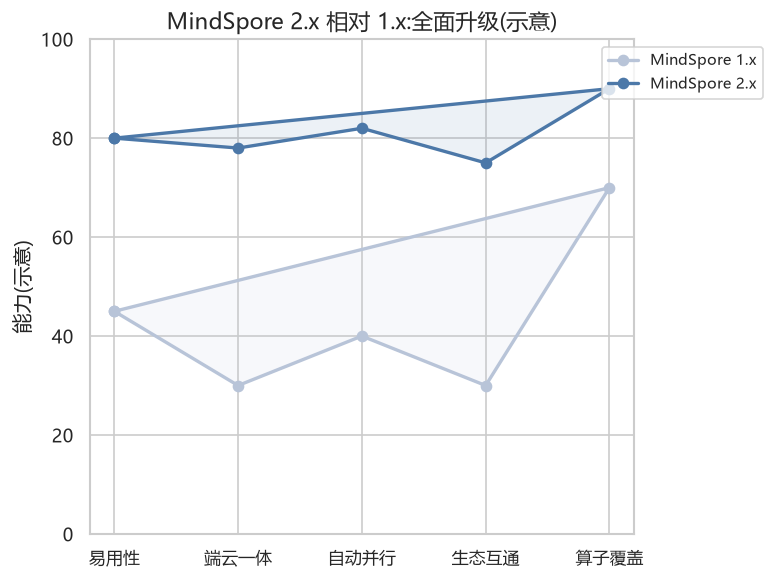

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 5.0))
dims = ["易用性", "端云一体", "自动并行", "生态互通", "算子覆盖"]
ms1 = [45, 30, 40, 30, 70]
ms2 = [80, 78, 82, 75, 90]
angles = np.linspace(0, 2 * np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]
for name, vals, color in [("MindSpore 1.x", ms1, "#B8C4D8"), ("MindSpore 2.x", ms2, "#4C78A8")]:
    v = vals + vals[:1]
    ax.plot(angles, v, marker="o", label=name, lw=2, color=color)
    ax.fill(angles, v, alpha=0.1, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(dims, fontsize=10)
ax.set_ylim(0, 100); ax.set_ylabel("能力(示意)")
ax.set_title("MindSpore 2.x 相对 1.x:全面升级(示意)", fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0), frameon=True, fontsize=9)
plt.tight_layout(); plt.show()

## 5️⃣ 与 PyTorch / vLLM 生态的关系 🤝

昇腾生态最有意思的地方,是它与“西方栈”的**融合**而非对抗:

- **torch_npu**:让 PyTorch 代码几乎不改就跑上昇腾(`import torch_npu` → `npu` device);
- **vLLM-Ascend**:vLLM 官方硬件插件,复用 vLLM 调度框架(第 84 课);
- **MindSpore**:训练侧自有,但导出的模型可经 ONNX/MindIR 喂给 vLLM-Ascend / MindIE。

画一张“两个世界如何握手”的示意图:

🤝 双向箭头 = 模型互通 + 框架适配。对工程师来说,这意味着“多一个选择”,而不是“多一门功课”。

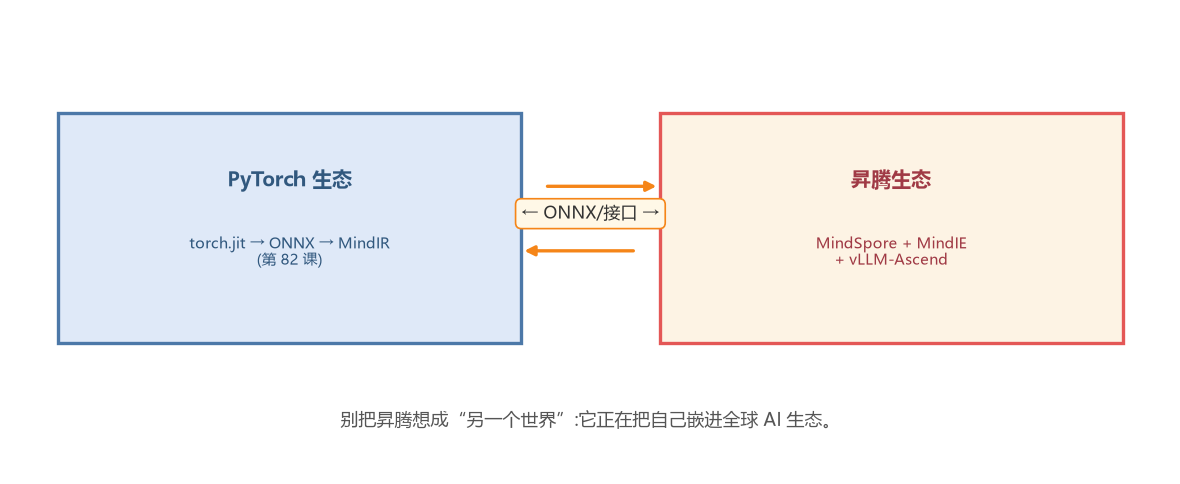

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.add_patch(plt.Rectangle((0.04, 0.28), 0.4, 0.5, fc="#DFE9F8", ec="#4C78A8", lw=2))
ax.text(0.24, 0.62, "PyTorch 生态", ha="center", fontsize=12, fontweight="bold", color="#31587E")
ax.text(0.24, 0.45, "torch.jit → ONNX → MindIR\n(第 82 课)", ha="center", fontsize=9, color="#31587E")
ax.add_patch(plt.Rectangle((0.56, 0.28), 0.4, 0.5, fc="#FDF3E4", ec="#E45756", lw=2))
ax.text(0.76, 0.62, "昇腾生态", ha="center", fontsize=12, fontweight="bold", color="#A03A45")
ax.text(0.76, 0.45, "MindSpore + MindIE\n+ vLLM-Ascend", ha="center", fontsize=9, color="#A03A45")
ax.text(0.5, 0.55, "← ONNX/接口 →", ha="center", fontsize=10, color="#333",
        bbox=dict(boxstyle="round,pad=0.35", fc="#FFF8E7", ec="#F58518"))
ax.annotate("", xy=(0.56, 0.62), xytext=(0.46, 0.62), arrowprops=dict(arrowstyle="-|>", color="#F58518", lw=2))
ax.annotate("", xy=(0.44, 0.48), xytext=(0.54, 0.48), arrowprops=dict(arrowstyle="-|>", color="#F58518", lw=2))
ax.text(0.5, 0.1, "别把昇腾想成“另一个世界”:它正在把自己嵌进全球 AI 生态。", ha="center", fontsize=10.5, color="#555")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.tight_layout(); plt.show()

## 6️⃣ 展望:下一站 🚀

把本书十章的 vLLM 知识放到昇腾生态里回看,你会发现“心法”全都通用:

- 连续批处理、PagedAttention、KV 分页 → MindIE / vLLM-Ascend 同样在做(第 84/85/88 课);
- 量化、自动并行、算子融合 → CANN 与 MindSpore 有对应实现(第 86/87/89 课);
- 你在这里练过的每一行 torch 代码,换块硬件、换个接口,依然成立。

最后画一张“本书知识 × 昇腾生态”的对应关系图,作为全书的收官注脚:

📊 六个 ✓ 意味着:第十一章不是“另一本书”,而是把前十章的知识翻译成了昇腾方言。恭喜你,整册《VLLM_learn》到此收官!🎉

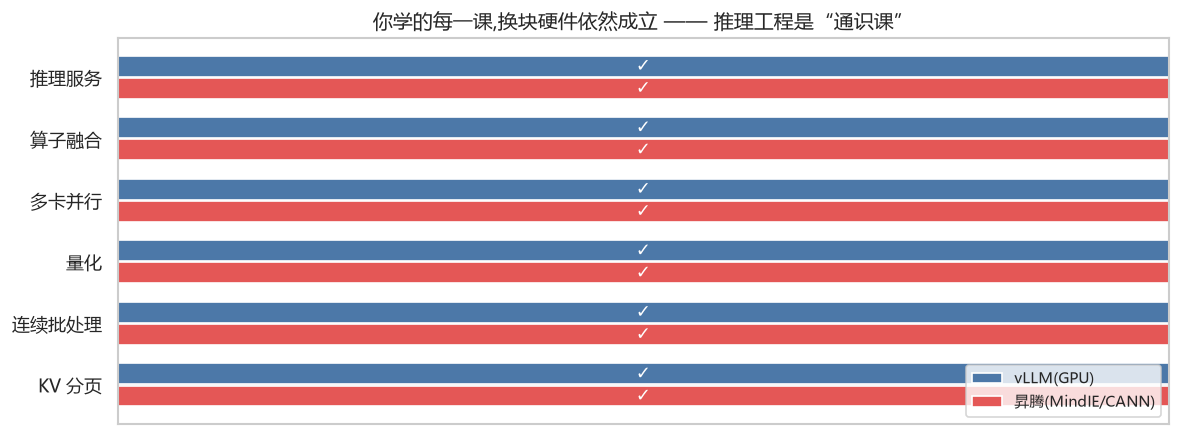

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.8))
topics = ["KV 分页", "连续批处理", "量化", "多卡并行", "算子融合", "推理服务"]
vllm = [1, 1, 1, 1, 1, 1]
ascend = [1, 1, 1, 1, 1, 1]
y = np.arange(len(topics))
ax.barh(y + 0.18, vllm, 0.34, color="#4C78A8", label="vLLM(GPU)")
ax.barh(y - 0.18, ascend, 0.34, color="#E45756", label="昇腾(MindIE/CANN)")
for yi in y:
    ax.text(0.5, yi + 0.18, "✓", ha="center", va="center", fontsize=11, color="white")
    ax.text(0.5, yi - 0.18, "✓", ha="center", va="center", fontsize=11, color="white")
ax.set_yticks(y); ax.set_yticklabels(topics)
ax.set_xticks([]); ax.set_xlim(0, 1)
ax.set_title("你学的每一课,换块硬件依然成立 —— 推理工程是“通识课”", fontsize=12)
ax.legend(frameon=True, fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

## ✅ 本课小结

- 2018→2026 七年时间线:硬件(310→910→910B→910C)与软件(CANN、MindSpore、MindIE)同步进化
- CANN 三步跃迁:5.x 配套 → 6.0 Ascend C → 8/9.x 平台化并服务大模型
- MindSpore 2.x 全面升级:易用性、端云一体、自动并行、生态互通
- 昇腾生态通过与 PyTorch 融合:torch_npu、ONNX/MindIR 互通、vLLM-Ascend 官方化
- 全书收官:连续批处理、分页、量化、并行、融合——换硬件全部成立

## ✍️ 动手练习

1. 把时间线图改造成“横向分组甘特图”,把 CANN 各版本的发布时间标注上去
2. 调研昇腾 910C 的公开算力与显存规格,把你估的爬坡曲线改成真实数据
3. 画一张“vLLM 术语 ↔ 昇腾术语”的对照表(如 PagedAttention↔PNA、NCCL↔HCCL、CUDA Graph↔GE)
4. 写一段 500 字总结:昇腾生态对开源社区最大的贡献是什么?为什么?

## 🔗 延伸阅读

- [昇腾社区](https://www.hiascend.com)
- [MindSpore 官网](https://www.mindspore.cn)
- [vLLM-Ascend GitHub](https://github.com/vllm-project/vllm-ascend)
- [MindIE 推理引擎](https://www.hiascend.com/zh/developer/techarticles)

---
> 🎉 恭喜完成本课!下一课见!